In [1]:
##Required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

sns.set(style="whitegrid")
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PRASHANT\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
#Reading the raw data
df = pd.read_csv("/AMAZON_REVIEW_SENTIMENT/data/raw/amazon_review_dataset.csv")
df.head()

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams


In [3]:
df.shape

(1597, 27)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1597 entries, 0 to 1596
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1597 non-null   object 
 1   asins                 1597 non-null   object 
 2   brand                 1597 non-null   object 
 3   categories            1597 non-null   object 
 4   colors                774 non-null    object 
 5   dateAdded             1597 non-null   object 
 6   dateUpdated           1597 non-null   object 
 7   dimension             565 non-null    object 
 8   ean                   898 non-null    float64
 9   keys                  1597 non-null   object 
 10  manufacturer          965 non-null    object 
 11  manufacturerNumber    902 non-null    object 
 12  name                  1597 non-null   object 
 13  prices                1597 non-null   object 
 14  reviews.date          1217 non-null   object 
 15  reviews.doRecommend  

In [5]:
df.describe()

,ean,reviews.numHelpful,reviews.rating,reviews.userCity,reviews.userProvince,sizes,upc
count,8.980000e+02,900.000000,1177.000000,0.0,0.0,0.0,8.980000e+02
mean,8.443135e+11,83.584444,4.359388,NaN,NaN,NaN,8.443135e+11
std,3.416444e+09,197.150238,1.021445,NaN,NaN,NaN,3.416444e+09
min,8.416670e+11,0.000000,1.000000,NaN,NaN,NaN,8.416670e+11
25%,8.416670e+11,0.000000,4.000000,NaN,NaN,NaN,8.416670e+11
50%,8.416670e+11,0.000000,5.000000,NaN,NaN,NaN,8.416670e+11
75%,8.487190e+11,34.000000,5.000000,NaN,NaN,NaN,8.487190e+11
max,8.487190e+11,997.000000,5.000000,NaN,NaN,NaN,8.487190e+11


In [6]:
df.columns

Index(['id', 'asins', 'brand', 'categories', 'colors', 'dateAdded',
       'dateUpdated', 'dimension', 'ean', 'keys', 'manufacturer',
       'manufacturerNumber', 'name', 'prices', 'reviews.date',
       'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.userCity', 'reviews.userProvince', 'reviews.username', 'sizes',
       'upc', 'weight'],
      dtype='object')

In [7]:
## Checking missing value
df.isnull().sum()

id                         0
asins                      0
brand                      0
categories                 0
colors                   823
dateAdded                  0
dateUpdated                0
dimension               1032
ean                      699
keys                       0
manufacturer             632
manufacturerNumber       695
name                       0
prices                     0
reviews.date             380
reviews.doRecommend     1058
reviews.numHelpful       697
reviews.rating           420
reviews.sourceURLs         0
reviews.text               0
reviews.title             17
reviews.userCity        1597
reviews.userProvince    1597
reviews.username          17
sizes                   1597
upc                      699
weight                   911
dtype: int64

In [8]:
##dropping missing review rating
df = df.dropna(subset=["reviews.rating"])
df.isnull().sum()

id                         0
asins                      0
brand                      0
categories                 0
colors                   508
dateAdded                  0
dateUpdated                0
dimension                620
ean                      484
keys                       0
manufacturer             451
manufacturerNumber       479
name                       0
prices                     0
reviews.date             217
reviews.doRecommend      638
reviews.numHelpful       277
reviews.rating             0
reviews.sourceURLs         0
reviews.text               0
reviews.title              0
reviews.userCity        1177
reviews.userProvince    1177
reviews.username           0
sizes                   1177
upc                      484
weight                   525
dtype: int64

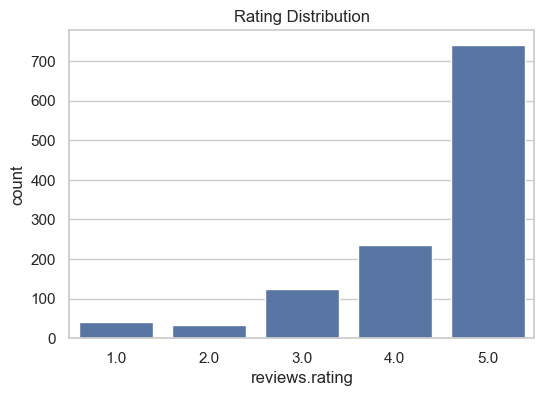

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="reviews.rating", data=df)
plt.title("Rating Distribution")
plt.show()

In [10]:
df = df[["reviews.text", "reviews.rating"]]


In [11]:
df

,reviews.text,reviews.rating
0,I initially had trouble deciding between the p...,5.0
1,Allow me to preface this with a little history...,5.0
2,I am enjoying it so far. Great for reading. Ha...,4.0
3,I bought one of the first Paperwhites and have...,5.0
4,I have to say upfront - I don't like coroporat...,5.0
...,...,...
1592,This is not the same remote that I got for my ...,3.0
1593,I have had to change the batteries in this rem...,1.0
1594,"Remote did not activate, nor did it connect to...",1.0
1595,It does the job but is super over priced. I fe...,3.0


In [12]:
df.shape

(1177, 2)

In [13]:
##defining a function for converting in sentiment label
def label_sentiment(rating):
    if rating >= 4:
        return 1   # Positive
    elif rating <= 2:
        return 0   # Negative
    else:
        return None  # Neutral (we drop these)

df["sentiment"] = df["reviews.rating"].apply(label_sentiment)

In [14]:
##Remove neutral review
df = df.dropna(subset=["sentiment"])
df["sentiment"].value_counts()

sentiment
1.0    977
0.0     76
Name: count, dtype: int64

##### OBSERVATION: Dataset is highly imbalanced where
##### Positive reviews : 977  (92.8%)
##### Negative reviews : 76   (7.2%)

##### Problem:  If we train model directly on this data,
##### model will be biased towards positive class
##### and will fail to detect negative reviews correctly

##### Solution: We will apply SMOTE + class_weight='balanced'
#####           before model training to handle this imbalance

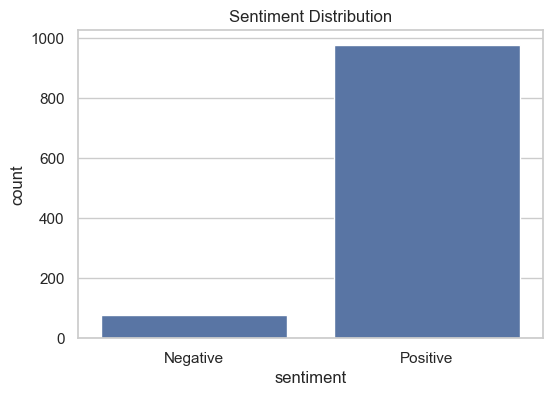

In [15]:
##Analyzing Sentiment Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="sentiment", data=df)
plt.xticks([0,1], ["Negative", "Positive"])
plt.title("Sentiment Distribution")
plt.show()

In [16]:
##REview Length analysis
df["review_length"] = df["reviews.text"].apply(len)
df["review_length"].describe()

C:\Users\PRASHANT\AppData\Local\Temp\ipykernel_9680\132644765.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["review_length"] = df["reviews.text"].apply(len)


count     1053.000000
mean       697.446344
std       1307.149798
min          3.000000
25%        106.000000
50%        262.000000
75%       1343.000000
max      19739.000000
Name: review_length, dtype: float64

In [17]:
# Find the outlier review
long_review = df[df["review_length"] == df["review_length"].max()]
print(long_review["reviews.text"].values[0][:500])
# Just print first 500 chars to see what it looks like

I am not a casual user of on-demand content and devices. Having tried smart tv's from 3 brands, smart dvd/bluray players, Apple TV, WDTV, HTPC, Chromecast and too many other competing products to mention--for streaming content, before this box you really had two options (for a simple to use box that doesn't require additional items or tweaking):First is Apple TV which is easy to use (interface) but Apple limits the content you can get greatly (including no Prime Streaming built in) and it lacks 


In [18]:
# How many reviews are above 3000 characters
print(df[df["review_length"] > 3000].shape[0])
print(df[df["review_length"] > 5000].shape[0])

10
6


#### Review Length Analysis

###### Mean: 697 chars, Max: 19,739 chars
###### High max is expected — Amazon tech reviewers
###### often write detailed comparison essays
###### Wide std (1307) reflects natural variation
###### from "Great!" to full product comparisons
###### No outlier removal needed

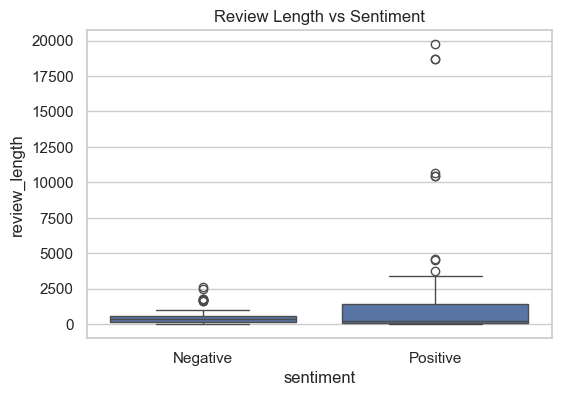

In [19]:
## Analyzing REview length vs Sentiment
plt.figure(figsize=(6,4))
sns.boxplot(x="sentiment", y="review_length", data=df)
plt.xticks([0,1], ["Negative", "Positive"])
plt.title("Review Length vs Sentiment")
plt.show()

In [20]:
##Define a function for cleaning text
def clean_text(text):
  text=str(text).lower()
  text = re.sub(r"http\S+", "", text)      # remove URLs
  text = re.sub(r"[^a-z\s]", "", text)     # keep only letters
  text = re.sub(r"\s+", " ", text).strip() # extra spaces
  words = text.split()
  words = [w for w in words if w not in stop_words]  # remove stopwords

  return " ".join(words)


df["Cleaned_Review"]=df["reviews.text"].apply(clean_text)
df = df.dropna(subset=["Cleaned_Review"])
df = df.dropna(subset=["Cleaned_Review"])
df = df[df["Cleaned_Review"].str.strip() != ""]

C:\Users\PRASHANT\AppData\Local\Temp\ipykernel_9680\1011960908.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Cleaned_Review"]=df["reviews.text"].apply(clean_text)


In [21]:
df.head()

,reviews.text,reviews.rating,sentiment,review_length,Cleaned_Review
0,I initially had trouble deciding between the p...,5.0,1.0,1064,initially trouble deciding paperwhite voyage r...
1,Allow me to preface this with a little history...,5.0,1.0,1424,allow preface little history casual reader own...
2,I am enjoying it so far. Great for reading. Ha...,4.0,1.0,182,enjoying far great reading original fire since...
3,I bought one of the first Paperwhites and have...,5.0,1.0,1671,bought one first paperwhites pleased constant ...
4,I have to say upfront - I don't like coroporat...,5.0,1.0,1916,say upfront dont like coroporate hermetically ...


In [22]:
df.shape

(1052, 5)

###  Positive box is higher and wider so it means people usally write more when giving positive feedback and while Most negative reviews are concentrated near the bottom so suggests people often write short complaints

In [23]:
df["reviews.text"][0]

"I initially had trouble deciding between the paperwhite and the voyage because reviews more or less said the same thing: the paperwhite is great, but if you have spending money, go for the voyage.Fortunately, I had friends who owned each, so I ended up buying the paperwhite on this basis: both models now have 300 ppi, so the 80 dollar jump turns out pricey the voyage's page press isn't always sensitive, and if you are fine with a specific setting, you don't need auto light adjustment).It's been a week and I am loving my paperwhite, no regrets! The touch screen is receptive and easy to use, and I keep the light at a specific setting regardless of the time of day. (In any case, it's not hard to change the setting either, as you'll only be changing the light level at a certain time of day, not every now and then while reading).Also glad that I went for the international shipping option with Amazon. Extra expense, but delivery was on time, with tracking, and I didnt need to worry about cu

In [24]:
df["Cleaned_Review"][0]

'initially trouble deciding paperwhite voyage reviews less said thing paperwhite great spending money go voyagefortunately friends owned ended buying paperwhite basis models ppi dollar jump turns pricey voyages page press isnt always sensitive fine specific setting dont need auto light adjustmentits week loving paperwhite regrets touch screen receptive easy use keep light specific setting regardless time day case hard change setting either youll changing light level certain time day every readingalso glad went international shipping option amazon extra expense delivery time tracking didnt need worry customs may used third party shipping service'

In [25]:
#Saving the cleaned data
df.to_csv("\AMAZON_REVIEW_SENTIMENT/data/processed/cleaned_data.csv", index=False)  

### Feature Engineering

In [26]:
## Reading Cleaned data
import pandas as pd

df = pd.read_csv(
    "\AMAZON_REVIEW_SENTIMENT\data\processed\cleaned_data.csv"
)

df.head()


,reviews.text,reviews.rating,sentiment,review_length,Cleaned_Review
0,I initially had trouble deciding between the p...,5.0,1.0,1064,initially trouble deciding paperwhite voyage r...
1,Allow me to preface this with a little history...,5.0,1.0,1424,allow preface little history casual reader own...
2,I am enjoying it so far. Great for reading. Ha...,4.0,1.0,182,enjoying far great reading original fire since...
3,I bought one of the first Paperwhites and have...,5.0,1.0,1671,bought one first paperwhites pleased constant ...
4,I have to say upfront - I don't like coroporat...,5.0,1.0,1916,say upfront dont like coroporate hermetically ...


In [27]:
##Selecting Input Column and Output Column
X=df["Cleaned_Review"]
y=df["sentiment"]

In [28]:
X

0       initially trouble deciding paperwhite voyage r...
1       allow preface little history casual reader own...
2       enjoying far great reading original fire since...
3       bought one first paperwhites pleased constant ...
4       say upfront dont like coroporate hermetically ...
                              ...                        
1047    voice remote gave nearly year purchased change...
1048    purchased first one tv fire box year ago gone ...
1049    change batteries remote twice per month since ...
1050    remote activate connect boxa poorly designed r...
1051    ordered item replace one longer works directio...
Name: Cleaned_Review, Length: 1052, dtype: object

In [29]:
y

0       1.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
1047    0.0
1048    0.0
1049    0.0
1050    0.0
1051    0.0
Name: sentiment, Length: 1052, dtype: float64

In [30]:
##Splitting data into training and testing
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
##Converting text into number using TF-IDF to understand for ML model
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer(max_features=2500,ngram_range=(1,2))

X_train_tfidf=tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)

In [32]:
#Balancing only train data using SMOTE(Synthetic Minority Oversampling)
# → Creates synthetic fake negative reviews
# → Brings negative class count equal to positive

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_tfidf, y_train)

In [33]:
# Confirm balancing worked
print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", dict(zip(*np.unique(y_train_balanced, return_counts=True))))

Before SMOTE: {1.0: 777, 0.0: 64}
After SMOTE : {0.0: 777, 1.0: 777}


In [34]:
## Training a model with technique class_weight='balanced'
# → It Tells model to pay more attention to minority class

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight="balanced")
model.fit(X_train_balanced, y_train_balanced)

LogisticRegression(class_weight='balanced')

In [35]:
## Evaluting a model
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.933649289099526
              precision    recall  f1-score   support

         0.0       0.36      0.36      0.36        11
         1.0       0.96      0.96      0.96       200

    accuracy                           0.93       211
   macro avg       0.66      0.66      0.66       211
weighted avg       0.93      0.93      0.93       211



In [36]:
import os
import pickle

#To out of notebooks folder
os.chdir(r'D:\AMAZON_REVIEW_SENTIMENT')

#Creating folder
os.makedirs('models', exist_ok=True)

#Save a vectorizer model
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

#Save a model
with open('models/model.pkl', 'wb') as f:
    pickle.dump(model, f)

##### CURRENT MODEL PERFORMANCE (Logistic Regression - Default)
#####
##### Overall Accuracy : 93.36%
#
##### Positive Class (1.0):
##### → Precision : 96%  — excellent ✅
##### → Recall    : 96%  — excellent ✅
##### → F1 Score  : 96%  — excellent ✅
#
##### Negative Class (0.0):
##### → Precision : 36%  — weak ⚠️
##### → Recall    : 36%  — weak ⚠️
##### → F1 Score  : 36%  — weak ⚠️
#
##### PROBLEM IDENTIFIED:
##### → Model is using DEFAULT parameters of LogisticRegression
##### → Default parameters are not always best for every dataset
##### → We need to find the BEST parameters for our specific data
#
##### SOLUTION: Apply GridSearchCV
##### → GridSearchCV tries every combination of parameters
##### → Finds which combination gives best performance
##### → Especially important for improving weak negative class

In [37]:
##Hyperparameter Tunning using GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=1000))
])
param_grid = {
    "tfidf__max_features": [1000, 2000, 3000],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [3, 5],
    "tfidf__max_df": [0.9, 0.95],

    "clf__C": [0.01, 0.1, 1, 10, 100],
    "clf__solver": ['liblinear', 'saga'],
    "clf__class_weight": ["balanced"]
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_macro",    #Best metric for NLP
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train,y_train)

print("Best Parameters:")
print(grid.best_params_)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Best Parameters:
{'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__solver': 'liblinear', 'tfidf__max_df': 0.9, 'tfidf__max_features': 1000, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}


#### “I used GridSearchCV with a pipeline to tune TF-IDF and Logistic Regression hyperparameters using F1-score, which is suitable for imbalanced sentiment datasets.

In [38]:
TfidfVectorizer()
LogisticRegression()

LogisticRegression()

In [39]:
##Converting text into number using TF-IDF to understand for ML model using GridSearchCV Hyperparameter Tunning best parameter
from sklearn.feature_extraction.text import TfidfVectorizer

gridtfidf=TfidfVectorizer(max_features=1000, ngram_range=(1,2), min_df=3, max_df=0.9)

X_train_gridtfidf=gridtfidf.fit_transform(X_train)
X_test_gridtfidf=gridtfidf.transform(X_test)

In [40]:
#Balancing only train data using SMOTE(Synthetic Minority Oversampling)
# → Creates synthetic fake negative reviews
# → Brings negative class count equal to positive

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_balanced_gridtfidf, y_train_balanced_gridtfidf = smote.fit_resample(X_train_gridtfidf, y_train)

In [41]:
## Training a model using GridSearchCV Hyperparameter Tunning best parameter
from sklearn.linear_model import LogisticRegression

best_model = LogisticRegression(C=1, solver="liblinear", class_weight="balanced")
best_model.fit(X_train_balanced_gridtfidf, y_train_balanced_gridtfidf)

LogisticRegression(C=1, class_weight='balanced', solver='liblinear')

In [42]:
## Evaluting a model
from sklearn.metrics import accuracy_score, classification_report

y_pred_gridtfidf = best_model.predict(X_test_gridtfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_gridtfidf))
print(classification_report(y_test, y_pred_gridtfidf))

Accuracy: 0.9241706161137441
              precision    recall  f1-score   support

         0.0       0.33      0.45      0.38        11
         1.0       0.97      0.95      0.96       200

    accuracy                           0.92       211
   macro avg       0.65      0.70      0.67       211
weighted avg       0.94      0.92      0.93       211



In [43]:
#Save final models

import os
import pickle

#To out of notebooks folder
os.chdir(r'D:\AMAZON_REVIEW_SENTIMENT')

#Creating folder
os.makedirs('final_models', exist_ok=True)

#Save a vectorizer model
with open('final_models/gridtfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(gridtfidf, f)

#Save a model
with open('final_models/sentiment_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

In [44]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)


In [45]:
# Load models
import os
import pickle

# Load TF-IDF vectorizer
with open('final_models/gridtfidf_vectorizer.pkl', 'rb') as f:
    gridtfidf = pickle.load(f)  

# Load trained model
with open('final_models/sentiment_model.pkl', 'rb') as f:
    best_model = pickle.load(f)  

# Confirm loaded successfully

print("TF-IDF loaded  :", type(gridtfidf))
print("Model loaded   :", type(best_model))


TF-IDF loaded  : <class 'sklearn.feature_extraction.text.TfidfVectorizer'>
Model loaded   : <class 'sklearn.linear_model._logistic.LogisticRegression'>


In [46]:
def predict_sentiment(review_text, expected=None):
    cleaned    = clean_text(review_text)
    vectorized = gridtfidf.transform([cleaned])
    prediction = best_model.predict(vectorized)[0]
    probability = best_model.predict_proba(vectorized)[0][int(prediction)]
    conf       = round(probability, 3)

    pred   = 'POSITIVE' if prediction == 1 else 'NEGATIVE'

    # symbol based on correct/wrong not just prediction
    if expected is not None:
        symbol = '✅' if pred in expected else '❌'
    else:
        symbol = '✅' if pred == 'POSITIVE' else '❌'

    label = f'{pred} {symbol}'

    return {
        "Review"     : review_text,
        "Cleaned"    : cleaned,
        "Prediction" : label,
        "Confidence" : conf
    }


In [47]:
##Testing Example 1
## Using very obvious words
review = "This product is amazing! Quality is excellent and totally worth the money."

result = predict_sentiment(review)
result


{'Review': 'This product is amazing! Quality is excellent and totally worth the money.',
 'Cleaned': 'product amazing quality excellent totally worth money',
 'Prediction': 'POSITIVE ✅',
 'Confidence': 0.612}

In [48]:
## Testing Example 2
## Using very obvious words
review = "This product is terrible. The quality is very poor and it is not worth the money at all."

result = predict_sentiment(review)
result

{'Review': 'This product is terrible. The quality is very poor and it is not worth the money at all.',
 'Cleaned': 'product terrible quality poor worth money',
 'Prediction': 'NEGATIVE ❌',
 'Confidence': 0.62}

In [49]:
## Testing Example 3
## Hard Positive Sentence

review = "Not bad at all! Initially I was worried but this product exceeded my expectations completely."

result = predict_sentiment(review)
result

{'Review': 'Not bad at all! Initially I was worried but this product exceeded my expectations completely.',
 'Cleaned': 'bad initially worried product exceeded expectations completely',
 'Prediction': 'NEGATIVE ❌',
 'Confidence': 0.544}

In [50]:
## Testing Example 4
## Hard Positive Sentence

review = "The packaging was nice and delivery was fast but the product itself is absolutely useless and stopped working within a week."

result = predict_sentiment(review)
result

{'Review': 'The packaging was nice and delivery was fast but the product itself is absolutely useless and stopped working within a week.',
 'Cleaned': 'packaging nice delivery fast product absolutely useless stopped working within week',
 'Prediction': 'POSITIVE ✅',
 'Confidence': 0.767}

#### Observation: Model predicts well on straightforward reviews using TF-IDF + Logistic Regression.
#### However, it struggles with sarcasm, mixed sentiment, and context-dependent reviews.
#### This is a known limitation of TF-IDF — it treats each word independently without understanding order or meaning.

#### So we need to Upgrade to LSTM with Word Embeddings to handle context and sequence better.